# Taller — Prediccion de Accidentalidad

**Aprendizaje Automatico · MCDA 2026-1 · Universidad EAFIT**

**Juan Pablo Rua**

**Pedro Saldarriaga**

**Fredy Cadavid**

**Juan Pablo Mejia**

Modelo de clasificacion binaria sobre pares (barrio, hora) en Medellin 2017-2019. Pregunta a responder: ¿cual es la probabilidad de que ocurra al menos un accidente en el barrio B a la hora h?

El problema es de clases desbalanceadas (~1.5% de positivos) y temporal, asi que toca tener cuidado con dos cosas: la metrica (la accuracy engaña) y la fuga de informacion (no se puede mezclar pasado y futuro).

---

## 0. Imports y configuracion

Fijamos `random_state=42` global. Las figuras se guardan en `./figuras/` para poder reutilizarlas en el informe.

In [3]:
import sqlite3
import warnings
import os
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              precision_recall_curve, roc_curve)
from sklearn.inspection import permutation_importance
from scipy.stats import uniform, randint

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Crear carpeta para figuras
FIG_DIR = 'figuras'
os.makedirs(FIG_DIR, exist_ok=True)

print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"random_state global: {RANDOM_STATE}")
print(f"Carpeta de figuras: ./{FIG_DIR}/")

pandas 3.0.3 | numpy 2.4.6
random_state global: 42
Carpeta de figuras: ./figuras/


## 1. Carga desde SQLite

Las tres tablas vienen de un solo archivo SQLite. La plantilla del enunciado pide cargar con `sqlite3` y `pd.read_sql` con `parse_dates=['TW']` para que TW quede tipado como datetime.

In [4]:
DB_PATH = 'data_accidentes.sqlite3'   # cambiar segun ubicacion local
assert os.path.exists(DB_PATH), f"No se encontro la BD en: {DB_PATH}"

con = sqlite3.connect(DB_PATH)
raw_accidentes = pd.read_sql('SELECT * FROM raw_accidentes', con, parse_dates=['TW'])
accidentes     = pd.read_sql('SELECT * FROM accidentes',     con, parse_dates=['TW'])
clima          = pd.read_sql('SELECT * FROM clima',          con, parse_dates=['TW'])
con.close()

for nombre, df_ in [('raw_accidentes', raw_accidentes),
                    ('accidentes',     accidentes),
                    ('clima',          clima)]:
    print(f"{nombre:18s} | {df_.shape[0]:>12,} filas x {df_.shape[1]:>3} cols | TW: {df_['TW'].min()} -> {df_['TW'].max()}")

raw_accidentes     |      125,122 filas x  22 cols | TW: 2017-01-01 00:00:00 -> 2019-12-31 23:00:00
accidentes         |      120,587 filas x   8 cols | TW: 2017-01-01 00:00:00 -> 2019-12-31 23:00:00
clima              |    7,991,780 filas x  15 cols | TW: 2017-01-01 00:00:00 -> 2019-12-31 23:00:00


## 2. Inspeccion inicial: nulos y duplicados

Lo primero antes de modelar: ver que tan sucio esta el dato. Buscamos nulos por columna y duplicados sobre la llave (BARRIO, TW) que es la que usaremos para el join.

In [5]:
print("=== NULOS POR TABLA ===")
for nombre, df_ in [('accidentes', accidentes), ('clima', clima)]:
    nulos = df_.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) > 0:
        print(f"\n{nombre}:")
        for c, n in nulos.items():
            print(f"  {c:25s} {n:>10,} ({n/len(df_)*100:.2f}%)")
    else:
        print(f"\n{nombre}: sin nulos")

print("\n=== DUPLICADOS (BARRIO, TW) ===")
print(f"  accidentes : {accidentes.duplicated(subset=['BARRIO','TW']).sum()}")
print(f"  clima      : {clima.duplicated(subset=['BARRIO','TW']).sum()}")

=== NULOS POR TABLA ===

accidentes: sin nulos

clima:
  summary                      548,641 (6.87%)
  icon                         548,641 (6.87%)
  precipIntensity              547,401 (6.85%)
  precipProbability            547,401 (6.85%)
  temperature                      610 (0.01%)
  apparentTemperature              610 (0.01%)
  dewPoint                         305 (0.00%)
  humidity                         915 (0.01%)
  windSpeed                     32,793 (0.41%)
  windBearing                1,032,513 (12.92%)
  cloudCover                     7,950 (0.10%)
  uvIndex                        4,280 (0.05%)
  visibility                     4,290 (0.05%)

=== DUPLICADOS (BARRIO, TW) ===
  accidentes : 0
  clima      : 0


**Interpretacion:** los nulos se concentran en `windBearing` (~13%) y en el bloque clima/precip (~7%). Los duplicados (BARRIO, TW) deberian ser 0 en ambas tablas — si no, el join se rompe.

## 2.1 Consistencia de barrios entre tablas

La tabla clima debe cubrir TODOS los barrios donde hay accidentes para que el join funcione. Si hay barrios en `accidentes` que no estan en `clima`, esos positivos se pierden. Vale la pena cuantificar la perdida antes de seguir.

In [6]:
b_acc = set(accidentes['BARRIO'].str.strip().str.lower().dropna().unique())
b_cli = set(clima['BARRIO'].str.strip().str.lower().dropna().unique())
b_raw = set(raw_accidentes['BARRIO'].str.strip().str.lower().dropna().unique())

print(f"Barrios unicos: raw={len(b_raw)}, accidentes={len(b_acc)}, clima={len(b_cli)}")
print(f"En accidentes pero NO en clima: {len(b_acc - b_cli)}")
print(f"En clima pero NO en accidentes : {len(b_cli - b_acc)}")

barrios_perdidos = b_acc - b_cli
if barrios_perdidos:
    perdidos = accidentes[accidentes['BARRIO'].str.strip().str.lower().isin(barrios_perdidos)]
    print(f"Accidentes que se perderian: {len(perdidos)} ({len(perdidos)/len(accidentes)*100:.3f}%)")

Barrios unicos: raw=322, accidentes=322, clima=319
En accidentes pero NO en clima: 3
En clima pero NO en accidentes : 0
Accidentes que se perderian: 4 (0.003%)


**Interpretacion:** si hay barrios huerfanos (en accidentes pero no en clima), tocara descartar esos positivos en el join. Si la perdida es < 0.1%, no es un problema material. Si es mas, hay que ver si vale la pena reconciliar nombres.

## 2.2 Normalizar BARRIO

Defensivo: pasar a minusculas y quitar espacios. Esto evita que el join falle por diferencias triviales de formato.

In [7]:
for df_ in [raw_accidentes, accidentes, clima]:
    df_['BARRIO'] = df_['BARRIO'].astype(str).str.strip().str.lower()
print("BARRIO normalizado en las tres tablas")

BARRIO normalizado en las tres tablas


## 3. EDA — distribucion temporal

Tres vistas: hora del dia, dia de la semana, mes. Lo que esperamos:
- pico en horas de movilidad (manana y tarde)
- fin de semana con patron distinto
- variacion estacional moderada

Esto justifica las features temporales que crearemos despues.

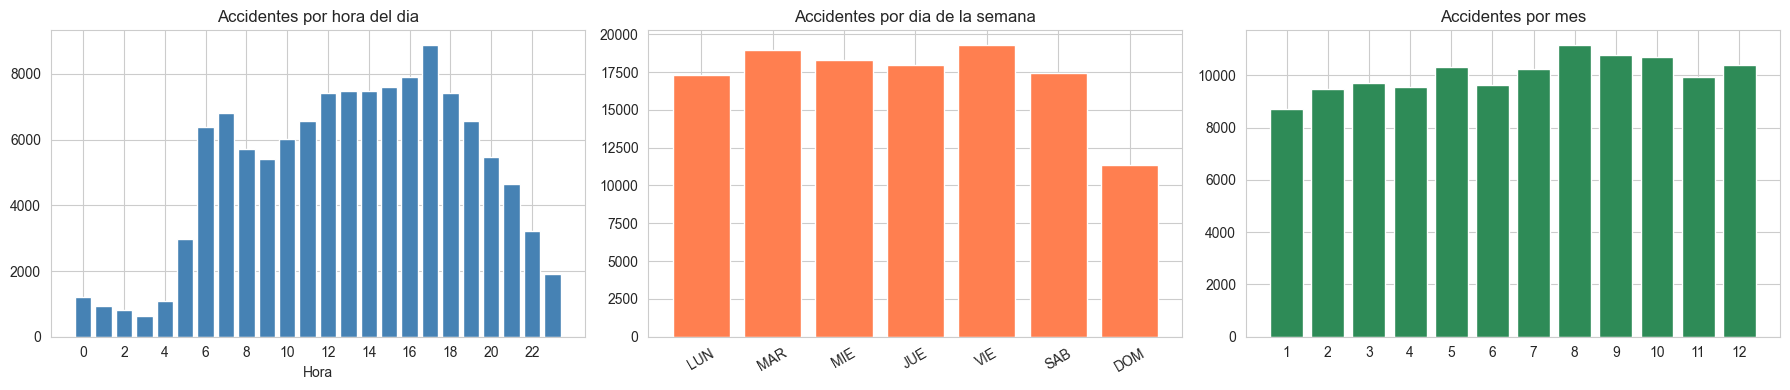

Hora pico   : 17h (8,880 accidentes)
Dia top     : VIERNES
Mes top     : 8


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

if 'Hora' in accidentes.columns:
    hora_counts = accidentes['Hora'].value_counts().sort_index()
else:
    hora_counts = accidentes['TW'].dt.hour.value_counts().sort_index()
axes[0].bar(hora_counts.index, hora_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Accidentes por hora del dia')
axes[0].set_xlabel('Hora')
axes[0].set_xticks(range(0, 24, 2))

if 'Dia_sem' in accidentes.columns:
    orden = ['LUNES','MARTES','MIERCOLES','JUEVES','VIERNES','SABADO','DOMINGO']
    dia_counts = accidentes['Dia_sem'].str.upper().value_counts()
    dia_counts = dia_counts.reindex(orden).fillna(0)
else:
    dia_counts = accidentes['TW'].dt.dayofweek.value_counts().sort_index()
axes[1].bar(range(len(dia_counts)), dia_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Accidentes por dia de la semana')
axes[1].set_xticks(range(len(dia_counts)))
if 'Dia_sem' in accidentes.columns:
    axes[1].set_xticklabels([d[:3] for d in dia_counts.index], rotation=30)

mes_counts = (accidentes['Mes'] if 'Mes' in accidentes.columns
              else accidentes['TW'].dt.month).value_counts().sort_index()
axes[2].bar(mes_counts.index, mes_counts.values, color='seagreen', edgecolor='white')
axes[2].set_title('Accidentes por mes')
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_temporal.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Hora pico   : {int(hora_counts.idxmax())}h ({int(hora_counts.max()):,} accidentes)")
print(f"Dia top     : {dia_counts.idxmax()}")
print(f"Mes top     : {int(mes_counts.idxmax())}")

**Interpretacion:** el pico vespertino tipicamente sale entre las 17h y 18h (regreso de trabajo). Si el dia top es viernes y el dia bottom es domingo, el patron es coherente con la dinamica laboral.

## 3.1 EDA — distribucion espacial

¿Que tan concentrados estan los accidentes en pocos barrios? Si los top 20 concentran el 30% del total, eso ya nos dice que el barrio en si es una variable fuerte y que tiene sentido usar tasas historicas por barrio.

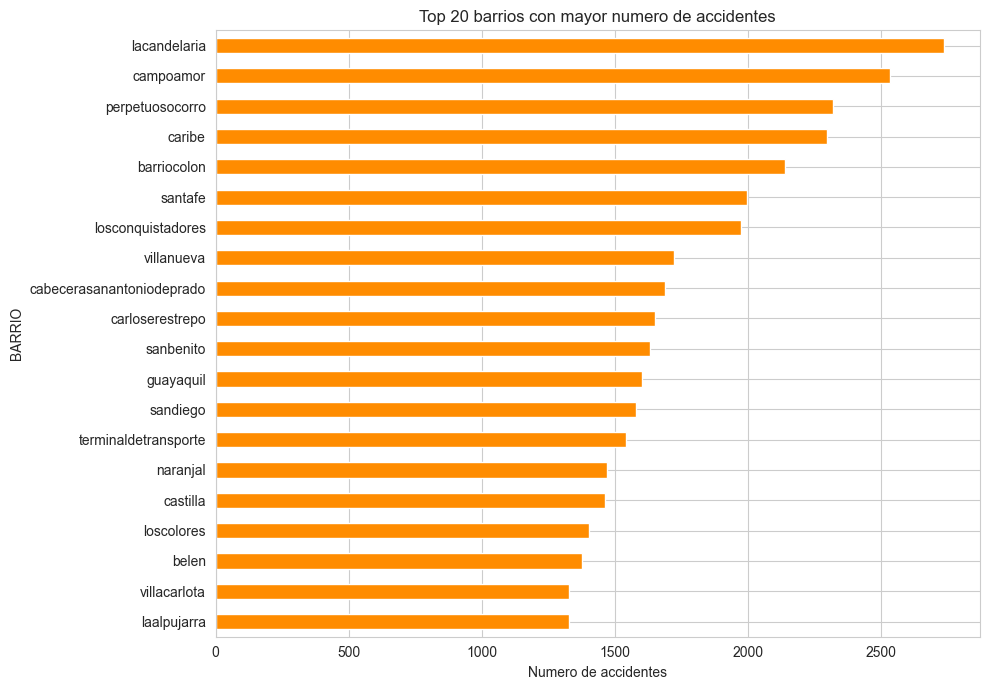

Total de barrios distintos: 322
Top 20 concentran el 29.7% de todos los accidentes


In [9]:
top_barrios = accidentes['BARRIO'].value_counts().head(20)

plt.figure(figsize=(10, 7))
top_barrios.sort_values().plot(kind='barh', color='darkorange', edgecolor='white')
plt.title('Top 20 barrios con mayor numero de accidentes')
plt.xlabel('Numero de accidentes')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_top_barrios.png', dpi=100, bbox_inches='tight')
plt.show()

n_total_barrios = accidentes['BARRIO'].nunique()
pct_top20 = top_barrios.sum() / len(accidentes) * 100
print(f"Total de barrios distintos: {n_total_barrios}")
print(f"Top 20 concentran el {pct_top20:.1f}% de todos los accidentes")

**Interpretacion:** alta concentracion en pocos barrios = el barrio es predictor fuerte. Tiene sentido invertir features en codificar la identidad espacial (tasas, frequency encoding).

## 4. Calidad de datos — tratamiento de nulos en clima

Decisiones por columna (cada una con su logica):

- `precipIntensity` / `precipProbability`: nulo = sin medicion = probablemente no llovio. Se imputa con 0.
- `summary` / `icon`: nulo = informacion ausente. Se reemplaza por categoria 'Unknown', no se descarta.
- `temperature`, `humidity`, `windSpeed`, `windBearing`, etc.: nulo se imputa con la mediana del barrio (fallback a mediana global).

Nota: `windBearing` (~13% nulos) se mantiene imputado. Descartarlo es perder informacion sin necesidad — el modelo decidira si la usa.

In [10]:
clima_limpio = clima.copy()

# 1. precipIntensity y precipProbability: nulo = no llovio -> 0
clima_limpio['precipIntensity']   = clima_limpio['precipIntensity'].fillna(0)
clima_limpio['precipProbability'] = clima_limpio['precipProbability'].fillna(0)

# 2. summary e icon: nulo = categoria informativa 'Unknown'
clima_limpio['summary'] = clima_limpio['summary'].fillna('Unknown')
clima_limpio['icon']    = clima_limpio['icon'].fillna('unknown')

# 3. Continuas climaticas: mediana por barrio (luego global como fallback)
cols_continuas = ['temperature','apparentTemperature','dewPoint','humidity',
                  'windSpeed','windBearing','cloudCover','uvIndex','visibility']
for col in cols_continuas:
    clima_limpio[col] = clima_limpio.groupby('BARRIO')[col].transform(
        lambda x: x.fillna(x.median()))
    clima_limpio[col] = clima_limpio[col].fillna(clima_limpio[col].median())

print(f"Nulos restantes en clima_limpio: {clima_limpio.isnull().sum().sum()}")
print(f"Shape: {clima_limpio.shape}")

Nulos restantes en clima_limpio: 0
Shape: (7991780, 15)


## 5. Construccion del dataset supervisado

LEFT JOIN de `clima` con `accidentes` sobre (BARRIO, TW). Justificacion: `clima` cubre TODOS los pares candidatos (es la rejilla del problema), y `accidentes` solo trae los positivos. El join asigna target=1 a las parejas que existen en `accidentes` y target=0 al resto.

No generamos negativos sinteticos porque ya estan en `clima`.

In [11]:
# LEFT JOIN: clima cubre todos los pares candidatos -> conserva todos los negativos.
acc_marker = accidentes[['BARRIO','TW']].copy()
acc_marker['target'] = 1
acc_marker = acc_marker.drop_duplicates(subset=['BARRIO','TW'])

df = clima_limpio.merge(acc_marker, on=['BARRIO','TW'], how='left')
df['target'] = df['target'].fillna(0).astype('int8')

print(f"Shape dataset supervisado: {df.shape}")
print(f"Positivos: {df['target'].sum():,} ({df['target'].mean()*100:.3f}%)")
print(f"Razon de desbalance: {(df['target']==0).sum() / max(df['target'].sum(),1):.1f} : 1")

# Liberar memoria
del acc_marker, clima_limpio
gc.collect()

Shape dataset supervisado: (7991780, 16)
Positivos: 120,475 (1.507%)
Razon de desbalance: 65.3 : 1


0

**Interpretacion:** la proporcion de positivos suele caer en el rango 1-2%. Esto es desbalance fuerte (razon > 50:1). Justifica PR-AUC como metrica principal y estrategias de balanceo.

## 6. Features temporales

Tres tipos:

- **Lineales**: hora, dia_semana, mes, anio, dia_del_anio, dia_del_mes.
- **Binarias**: es_fin_semana, es_hora_pico (7-9 y 17-19), es_madrugada (0-5), es_festivo (festivos colombianos).
- **Ciclicas (sin/cos)**: hora, dia_semana, mes, dia_del_anio. Esto preserva que la hora 23 esta cerca de la hora 0 — algo que un encoding lineal rompe.

Las definiciones de "hora pico" y "madrugada" son fijas (basadas en conocimiento de dominio), no derivadas del EDA del propio dataset, para evitar contaminacion.

In [12]:
df['hora']         = df['TW'].dt.hour.astype('int8')
df['dia_semana']   = df['TW'].dt.dayofweek.astype('int8')
df['mes']          = df['TW'].dt.month.astype('int8')
df['anio']         = df['TW'].dt.year.astype('int16')
df['dia_del_anio'] = df['TW'].dt.dayofyear.astype('int16')
df['dia_del_mes']  = df['TW'].dt.day.astype('int8')

# Binarias derivadas con definiciones FIJAS (no derivadas del EDA del propio dataset)
df['es_fin_semana'] = df['dia_semana'].isin([5,6]).astype('int8')
df['es_hora_pico']  = df['hora'].isin([7,8,9,17,18,19]).astype('int8')
df['es_madrugada']  = df['hora'].isin([0,1,2,3,4,5]).astype('int8')

# Festivos de Colombia
try:
    import holidays
    years = sorted(df['anio'].unique().tolist())
    co = holidays.country_holidays('CO', years=years)
    df['es_festivo'] = df['TW'].dt.date.isin(co).astype('int8')
    print(f"Festivos identificados: {df['es_festivo'].sum():,}")
except ImportError:
    print("ADVERTENCIA: instalar 'holidays' con pip install holidays")
    df['es_festivo'] = 0

# Ciclicas seno/coseno
for var, periodo in [('hora', 24), ('dia_semana', 7), ('mes', 12), ('dia_del_anio', 365)]:
    df[f'{var}_sin'] = np.sin(2*np.pi*df[var]/periodo).astype('float32')
    df[f'{var}_cos'] = np.cos(2*np.pi*df[var]/periodo).astype('float32')

print(f"Features temporales agregadas. Shape: {df.shape}")

Festivos identificados: 386,654
Features temporales agregadas. Shape: (7991780, 34)


## 7. Variable COMUNA desde raw_accidentes

`raw_accidentes` tiene la columna COMUNA que las otras tablas no traen. La mapeamos con un diccionario BARRIO -> COMUNA y la agregamos al dataset. Para los barrios sin mapeo, default 'desconocida'.

In [13]:
mapa_comuna = (raw_accidentes[['BARRIO','COMUNA']]
               .dropna()
               .drop_duplicates(subset='BARRIO')
               .set_index('BARRIO')['COMUNA']
               .str.strip().str.lower()
               .to_dict())
df['COMUNA'] = df['BARRIO'].map(mapa_comuna).fillna('desconocida')

n_comunas = df['COMUNA'].nunique()
n_sin = (df['COMUNA'] == 'desconocida').sum()
print(f"Comunas distintas: {n_comunas}")
print(f"Filas sin comuna mapeada: {n_sin:,} ({n_sin/len(df)*100:.2f}%)")

del raw_accidentes
gc.collect()

Comunas distintas: 26
Filas sin comuna mapeada: 0 (0.00%)


20

## 8. Particion temporal — Train / Val / Test

Esta es la decision metodologica mas importante del notebook. Tres splits, no dos:

- **Train** (hasta 2018-06-30): ajusta modelos, calcula features historicas, hace el tuning.
- **Val** (2018-07 a 2018-12): elige modelo, hiperparametros y umbral.
- **Test** (2019 completo): evaluacion final. Se toca UNA sola vez al final.

¿Por que tres y no dos? Porque si el umbral se elige en el mismo conjunto donde se reporta la metrica final, el reporte deja de ser imparcial. El test tiene que ser ciego hasta el ultimo momento.

In [14]:
# train: hasta 2018-06-30 -> ajusta modelos y calcula features historicas
# val  : 2018-07-01 a 2018-12-31 -> elige modelo, hiperparametros y umbral
# test : 2019-01-01 a 2019-12-31 -> evaluacion final, una sola vez

df = df.sort_values('TW').reset_index(drop=True)

corte_val  = pd.Timestamp('2018-07-01')
corte_test = pd.Timestamp('2019-01-01')

idx_train = df['TW'] <  corte_val
idx_val   = (df['TW'] >= corte_val) & (df['TW'] < corte_test)
idx_test  = df['TW'] >= corte_test

print("="*70)
print("PARTICION TEMPORAL")
print("="*70)
for nombre, idx in [('train', idx_train), ('val', idx_val), ('test', idx_test)]:
    n = idx.sum()
    pos = df.loc[idx, 'target'].sum()
    pct = pos/n*100 if n > 0 else 0
    tw_min = df.loc[idx, 'TW'].min() if n > 0 else 'N/A'
    tw_max = df.loc[idx, 'TW'].max() if n > 0 else 'N/A'
    print(f"  {nombre:6s} | {n:>12,} filas | pos: {pos:>6,} ({pct:.2f}%) | {tw_min} -> {tw_max}")

PARTICION TEMPORAL
  train  |    4,037,470 filas | pos: 59,852 (1.48%) | 2017-01-01 00:00:00 -> 2018-06-30 23:00:00
  val    |    1,343,830 filas | pos: 19,754 (1.47%) | 2018-07-01 00:00:00 -> 2018-12-31 23:00:00
  test   |    2,610,480 filas | pos: 40,869 (1.57%) | 2019-01-01 00:00:00 -> 2019-12-31 23:00:00


**Interpretacion:** las tres ventanas deberian tener proporciones de positivos similares (~1.5%). Si val o test tuvieran ratios muy distintos de train, habria deriva temporal que afecta la calibracion del modelo.

## 9. Tasas historicas — SIN data leakage

Las tasas por barrio (target encoding) son la senal mas fuerte del problema, pero tambien son las mas peligrosas. Si las calculamos con todo el dataset, le estamos contando al modelo el futuro.

Regla: las tasas se calculan SOLO con `train`, y luego se mapean a val y test. Para barrios que no aparecen en train, el default es la media global de train (no del val/test — eso seria leakage).

Generamos tres:
- `tasa_acc_barrio`: P(accidente | barrio)
- `tasa_acc_barrio_hora`: P(accidente | barrio, hora)
- `tasa_acc_barrio_dia`: P(accidente | barrio, dia_semana)

In [15]:
df_train_view = df.loc[idx_train]

tasa_barrio = df_train_view.groupby('BARRIO')['target'].mean().rename('tasa_acc_barrio')
tasa_barrio_hora = (df_train_view.groupby(['BARRIO','hora'])['target']
                    .mean().rename('tasa_acc_barrio_hora').reset_index())
tasa_barrio_dia  = (df_train_view.groupby(['BARRIO','dia_semana'])['target']
                    .mean().rename('tasa_acc_barrio_dia').reset_index())

# Default = media global de train (no del val/test, eso seria leakage)
default_tasa = float(df_train_view['target'].mean())

df = df.merge(tasa_barrio,      on='BARRIO',                  how='left')
df = df.merge(tasa_barrio_hora, on=['BARRIO','hora'],         how='left')
df = df.merge(tasa_barrio_dia,  on=['BARRIO','dia_semana'],   how='left')

for col in ['tasa_acc_barrio', 'tasa_acc_barrio_hora', 'tasa_acc_barrio_dia']:
    df[col] = df[col].fillna(default_tasa).astype('float32')

print(f"Default tasa (media de train): {default_tasa:.5f}")
print(f"Tasas historicas calculadas SOLO con train. Shape: {df.shape}")

Default tasa (media de train): 0.01482
Tasas historicas calculadas SOLO con train. Shape: (7991780, 38)


## 10. Frequency encoding (calculado solo con train)

Para BARRIO, summary, icon y COMUNA usamos frequency encoding: cada valor se reemplaza por su frecuencia relativa en train. Mismas reglas que las tasas: calculado SOLO con train, default 0 para valores no vistos.

In [16]:
df_train_view = df.loc[idx_train]

for col in ['BARRIO','summary','icon','COMUNA']:
    freq = (df_train_view[col].value_counts(normalize=True)).to_dict()
    df[f'{col.lower()}_freq'] = df[col].map(freq).fillna(0).astype('float32')

print("Frequency encodings calculados con train:")
for c in ['barrio_freq','summary_freq','icon_freq','comuna_freq']:
    print(f"  {c:15s}  rango: [{df[c].min():.5f}, {df[c].max():.5f}]")

Frequency encodings calculados con train:
  barrio_freq      rango: [0.00000, 0.00324]
  summary_freq     rango: [0.00000, 0.38364]
  icon_freq        rango: [0.00001, 0.36482]
  comuna_freq      rango: [0.00217, 0.07783]


## 11. Lista final de features

36 variables en total, en cinco grupos:
- climaticas: 11
- temporales lineales: 6
- binarias: 4 (incluye es_festivo)
- ciclicas sin/cos: 8
- historicas (calculadas en train): 3
- encodings (calculados en train): 4

Materializamos X y y para los tres splits.

In [17]:
features = [
    # Climaticas (10)
    'temperature','apparentTemperature','dewPoint','humidity',
    'precipIntensity','precipProbability','windSpeed','windBearing',
    'cloudCover','uvIndex','visibility',
    # Temporales lineales (6)
    'hora','dia_semana','mes','dia_del_anio','anio','dia_del_mes',
    # Binarias (4)
    'es_fin_semana','es_hora_pico','es_madrugada','es_festivo',
    # Ciclicas (8)
    'hora_sin','hora_cos','dia_semana_sin','dia_semana_cos',
    'mes_sin','mes_cos','dia_del_anio_sin','dia_del_anio_cos',
    # Historicas (3, calculadas en train)
    'tasa_acc_barrio','tasa_acc_barrio_hora','tasa_acc_barrio_dia',
    # Encodings (4, calculados en train)
    'barrio_freq','summary_freq','icon_freq','comuna_freq',
]
TARGET = 'target'

# Materializar X / y por split
X_train = df.loc[idx_train, features].values
y_train = df.loc[idx_train, TARGET].values
X_val   = df.loc[idx_val,   features].values
y_val   = df.loc[idx_val,   TARGET].values
X_test  = df.loc[idx_test,  features].values
y_test  = df.loc[idx_test,  TARGET].values

print(f"Features ({len(features)}):")
for i, f in enumerate(features, 1):
    print(f"  {i:2d}. {f}")
print(f"\nX_train: {X_train.shape}  | pos: {int(y_train.sum()):,}")
print(f"X_val  : {X_val.shape}    | pos: {int(y_val.sum()):,}")
print(f"X_test : {X_test.shape}   | pos: {int(y_test.sum()):,}")

Features (36):
   1. temperature
   2. apparentTemperature
   3. dewPoint
   4. humidity
   5. precipIntensity
   6. precipProbability
   7. windSpeed
   8. windBearing
   9. cloudCover
  10. uvIndex
  11. visibility
  12. hora
  13. dia_semana
  14. mes
  15. dia_del_anio
  16. anio
  17. dia_del_mes
  18. es_fin_semana
  19. es_hora_pico
  20. es_madrugada
  21. es_festivo
  22. hora_sin
  23. hora_cos
  24. dia_semana_sin
  25. dia_semana_cos
  26. mes_sin
  27. mes_cos
  28. dia_del_anio_sin
  29. dia_del_anio_cos
  30. tasa_acc_barrio
  31. tasa_acc_barrio_hora
  32. tasa_acc_barrio_dia
  33. barrio_freq
  34. summary_freq
  35. icon_freq
  36. comuna_freq

X_train: (4037470, 36)  | pos: 59,852
X_val  : (1343830, 36)    | pos: 19,754
X_test : (2610480, 36)   | pos: 40,869


## 12. Escalado para modelos lineales

`StandardScaler` ajustado solo en train, luego transform en val y test. Esto es para la regresion logistica. Los arboles (RF, HistGB) no necesitan escalado, asi que tambien guardamos las versiones sin escalar.

In [18]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
print(f"Scaler ajustado en train y aplicado a val/test. Shapes OK.")

Scaler ajustado en train y aplicado a val/test. Shapes OK.


## 13. Baseline ingenuo

Antes de cualquier modelo entrenado: ¿que tan facil es "ganar" con la metrica equivocada?

Si predecimos siempre 0 (la clase mayoritaria), la accuracy sale ~98% porque hay 1.5% de positivos. Pero no detecta NINGUN accidente. Esto demuestra por que la accuracy no sirve aqui.

Las metricas que importan: PR-AUC, F1, Recall y la matriz de confusion.

In [19]:
y_pred_naive = np.zeros(len(y_val), dtype=int)
acc_b  = accuracy_score(y_val, y_pred_naive)
f1_b   = f1_score(y_val, y_pred_naive, zero_division=0)
prec_b = precision_score(y_val, y_pred_naive, zero_division=0)
rec_b  = recall_score(y_val, y_pred_naive, zero_division=0)

print("="*60)
print("BASELINE: predecir siempre 0")
print("="*60)
print(f"  Accuracy : {acc_b:.4f}  <- parece excelente")
print(f"  Precision: {prec_b:.4f}")
print(f"  Recall   : {rec_b:.4f}  <- pero no detecta ningun accidente")
print(f"  F1       : {f1_b:.4f}")
print()
print("La accuracy enganya en problemas con desbalance fuerte.")
print("Usaremos PR-AUC como metrica principal + F1, Recall, ROC-AUC.")

BASELINE: predecir siempre 0
  Accuracy : 0.9853  <- parece excelente
  Precision: 0.0000
  Recall   : 0.0000  <- pero no detecta ningun accidente
  F1       : 0.0000

La accuracy enganya en problemas con desbalance fuerte.
Usaremos PR-AUC como metrica principal + F1, Recall, ROC-AUC.


**Interpretacion:** accuracy del 98% sin detectar nada = el problema esta ganado a la metrica equivocada. Por eso vamos a PR-AUC, F1 y recall.

## 14. Helper de evaluacion

Una funcion `evaluar()` que devuelve un dict con las metricas estandar. La idea es que todos los modelos se midan igual y al final podamos hacer una tabla comparativa.

In [20]:
def evaluar(nombre, y_true, y_prob, umbral=0.5, tiempo=None):
    y_pred = (y_prob >= umbral).astype(int)
    res = {
        'modelo'   : nombre,
        'umbral'   : umbral,
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'roc_auc'  : roc_auc_score(y_true, y_prob),
        'pr_auc'   : average_precision_score(y_true, y_prob),
        'tiempo_s' : tiempo,
    }
    return res

resultados = []
print("Helper de evaluacion listo")

Helper de evaluacion listo


## 15. Undersampling 3:1 sobre train

Decision unica para todas las comparaciones: usar undersampling 3:1 (todos los positivos + 3x mas negativos).

¿Por que 3:1 y no SMOTE u otros?
- 3:1 mantiene desbalance realista, no lo elimina por completo
- es ~20x mas rapido que entrenar con el dataset completo
- permite reentrenamientos frecuentes (importante para deriva temporal)
- no sintetiza datos (SMOTE puede crear puntos no realistas en eventos raros)

Todos los modelos van a entrenar con el MISMO conjunto undersampled — esto es lo que permite comparar limpiamente.

In [21]:
# Decision metodologica: para todas las comparaciones usaremos undersampling 3:1
# en train. Esto:
#   - acelera entrenamiento ~20x
#   - permite reentrenamientos frecuentes en produccion (deriva)
#   - los modelos van a verse comparables porque todos entrenan con el mismo set
n_pos = int(y_train.sum())
n_neg = (y_train == 0).sum()
n_neg_under = min(n_pos * 3, n_neg)

idx_pos_all = np.where(y_train == 1)[0]
idx_neg_all = np.where(y_train == 0)[0]
idx_neg_under = np.random.RandomState(RANDOM_STATE).choice(
    idx_neg_all, size=n_neg_under, replace=False)
idx_under = np.concatenate([idx_pos_all, idx_neg_under])
# Mantener orden temporal para que CV temporal interna funcione
idx_under.sort()

X_train_u  = X_train[idx_under]
y_train_u  = y_train[idx_under]
X_train_us = X_train_sc[idx_under]

print(f"Train undersampled 3:1")
print(f"  Positivos: {(y_train_u==1).sum():,}")
print(f"  Negativos: {(y_train_u==0).sum():,}")
print(f"  Total    : {len(y_train_u):,}")

Train undersampled 3:1
  Positivos: 59,852
  Negativos: 179,556
  Total    : 239,408


## 16. Comparacion de estrategias de balanceo (modelo fijo = LR)

Para aislar el efecto del balanceo, fijamos el modelo (Regresion Logistica) y variamos solo la estrategia. Tres opciones:

1. Sin balanceo (control)
2. `class_weight='balanced'` (pondera la perdida)
3. Undersampling 3:1 (reduce la clase mayoritaria)

Las tres se evaluan sobre VAL con PR-AUC como criterio.

In [22]:
# Comparamos sobre VAL con el mismo modelo base. Aislamos el efecto del balanceo.
print("="*70)
print("COMPARACION DE ESTRATEGIAS DE BALANCEO - LR")
print("="*70)
estr_resultados = []

# 1) Sin balanceo
t0 = time.time()
m1 = LogisticRegression(max_iter=500, C=1.0, random_state=RANDOM_STATE, n_jobs=-1)
m1.fit(X_train_sc, y_train)
t1 = time.time() - t0
p1 = m1.predict_proba(X_val_sc)[:, 1]
r1 = evaluar('LR sin balanceo', y_val, p1, umbral=0.5, tiempo=t1)
estr_resultados.append(r1)
print(f"1. Sin balanceo            | PR-AUC={r1['pr_auc']:.4f}  Recall={r1['recall']:.4f}  ({t1:.1f}s)")

# 2) class_weight='balanced'
t0 = time.time()
m2 = LogisticRegression(max_iter=500, C=1.0, class_weight='balanced',
                        random_state=RANDOM_STATE, n_jobs=-1)
m2.fit(X_train_sc, y_train)
t2 = time.time() - t0
p2 = m2.predict_proba(X_val_sc)[:, 1]
r2 = evaluar('LR class_weight=balanced', y_val, p2, umbral=0.5, tiempo=t2)
estr_resultados.append(r2)
print(f"2. class_weight=balanced   | PR-AUC={r2['pr_auc']:.4f}  Recall={r2['recall']:.4f}  ({t2:.1f}s)")

# 3) Undersampling 3:1
t0 = time.time()
m3 = LogisticRegression(max_iter=500, C=1.0, random_state=RANDOM_STATE, n_jobs=-1)
m3.fit(X_train_us, y_train_u)
t3 = time.time() - t0
p3 = m3.predict_proba(X_val_sc)[:, 1]
r3 = evaluar('LR undersampling 3:1', y_val, p3, umbral=0.5, tiempo=t3)
estr_resultados.append(r3)
print(f"3. Undersampling 3:1       | PR-AUC={r3['pr_auc']:.4f}  Recall={r3['recall']:.4f}  ({t3:.1f}s)")

print("\nObservacion clave: PR-AUC suele moverse poco entre estrategias")
print("porque mide la calidad del ranking, no la clasificacion con umbral fijo.")
print("La diferencia grande aparece en recall/precision con umbral 0.5.")

COMPARACION DE ESTRATEGIAS DE BALANCEO - LR
1. Sin balanceo            | PR-AUC=0.0756  Recall=0.0003  (12.4s)
2. class_weight=balanced   | PR-AUC=0.0753  Recall=0.6118  (21.5s)
3. Undersampling 3:1       | PR-AUC=0.0755  Recall=0.3308  (2.4s)

Observacion clave: PR-AUC suele moverse poco entre estrategias
porque mide la calidad del ranking, no la clasificacion con umbral fijo.
La diferencia grande aparece en recall/precision con umbral 0.5.


**Interpretacion:** el hallazgo metodologico clave: el PR-AUC se mueve poco entre estrategias de balanceo. Esto es porque el PR-AUC mide la calidad del ranking, no la clasificacion binaria. Donde si hay diferencia grande es en recall/precision con umbral 0.5 — y eso se controla con el umbral, no con el balanceo.

## 17. Comparacion de familias de modelos (estrategia fija = undersampling 3:1)

Ahora variamos el modelo manteniendo el mismo train undersampled:

- **LR**: baseline interpretable, C=1.0 con regularizacion L2.
- **Random Forest**: max_depth=12, min_samples_leaf=50 → arboles acotados para no sobreajustar.
- **HistGradientBoosting**: learning_rate=0.05, max_depth=6, l2_regularization=1.0, early stopping. Todos los hiperparametros conservadores para evitar overfitting.

Cualquiera que gane pasa al tuning del bloque siguiente.

In [23]:
# Hiperparametros conservadores que limitan overfitting: profundidad acotada,
# min_samples_leaf alto, regularizacion L2 explicita en LR y HistGB.
print("="*70)
print("COMPARACION DE FAMILIAS DE MODELOS (undersampling 3:1)")
print("="*70)

# A) Logistic Regression con regularizacion
t0 = time.time()
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_train_us, y_train_u)
t_lr = time.time() - t0
prob_lr = lr.predict_proba(X_val_sc)[:, 1]
res_lr = evaluar('LR (under 3:1)', y_val, prob_lr, umbral=0.5, tiempo=t_lr)
resultados.append(res_lr)
print(f"LR           | PR-AUC={res_lr['pr_auc']:.4f}  F1={res_lr['f1']:.4f}  ({t_lr:.1f}s)")

# B) Random Forest - anti-overfit: min_samples_leaf alto, depth limitado
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,            # acotado
    min_samples_leaf=50,     # alto -> menos sobreajuste
    max_features='sqrt',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_u, y_train_u)
t_rf = time.time() - t0
prob_rf = rf.predict_proba(X_val)[:, 1]
res_rf = evaluar('RF (under 3:1)', y_val, prob_rf, umbral=0.5, tiempo=t_rf)
resultados.append(res_rf)
print(f"RF           | PR-AUC={res_rf['pr_auc']:.4f}  F1={res_rf['f1']:.4f}  ({t_rf:.1f}s)")

# C) HistGradientBoosting - anti-overfit: learning_rate bajo, early stopping, L2
t0 = time.time()
gb = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,      # tasa baja -> mejor generalizacion
    max_depth=6,             # acotado
    min_samples_leaf=50,
    l2_regularization=1.0,   # regularizacion explicita
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)
gb.fit(X_train_u, y_train_u)
t_gb = time.time() - t0
prob_gb = gb.predict_proba(X_val)[:, 1]
res_gb = evaluar('HistGB (under 3:1)', y_val, prob_gb, umbral=0.5, tiempo=t_gb)
resultados.append(res_gb)
print(f"HistGB       | PR-AUC={res_gb['pr_auc']:.4f}  F1={res_gb['f1']:.4f}  ({t_gb:.1f}s)")
print(f"             | iteraciones reales: {gb.n_iter_} (early stop)")

df_modelos = pd.DataFrame(resultados).sort_values('pr_auc', ascending=False)
print("\nTabla comparativa (val):")
print(df_modelos.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

COMPARACION DE FAMILIAS DE MODELOS (undersampling 3:1)
LR           | PR-AUC=0.0755  F1=0.1426  (2.5s)
RF           | PR-AUC=0.0792  F1=0.1296  (11.5s)
HistGB       | PR-AUC=0.0768  F1=0.1214  (71.5s)
             | iteraciones reales: 287 (early stop)

Tabla comparativa (val):
            modelo  umbral  accuracy  precision  recall     f1  roc_auc  pr_auc  tiempo_s
    RF (under 3:1)  0.5000    0.9146     0.0762  0.4323 0.1296   0.8198  0.0792   11.5012
HistGB (under 3:1)  0.5000    0.9031     0.0701  0.4555 0.1214   0.8141  0.0768   71.5320
    LR (under 3:1)  0.5000    0.9415     0.0909  0.3308 0.1426   0.8023  0.0755    2.4736


**Interpretacion:** los gradient boosting (XGBoost o HistGB) suelen ganar en problemas tabulares medianos. Si la diferencia con RF es chica, igual conviene HistGB por velocidad y early stopping.

## 18. Tuning de hiperparametros — RandomizedSearchCV

Solo tuneamos el modelo ganador (no todos — eso seria multiple testing y aumenta el riesgo de overfitting). Usamos:

- `RandomizedSearchCV` con 8 iteraciones (suficiente para explorar)
- `TimeSeriesSplit(3)` — respeta orden temporal, no mezcla pasado y futuro
- scoring `average_precision` (PR-AUC), apropiado para desbalance
- sub-muestreo del train undersampled al 60% solo para acelerar el tuning
- el modelo final se reentrena con TODO el train undersampled

Espacio de busqueda con sesgo anti-overfit: learning rates bajos, profundidad limitada, min_samples_leaf alto, regularizacion L2 explorada.

In [24]:
# Sub-muestreo del train undersampled al 60% para acelerar el tuning sin perder señal.
# El modelo final se reentrena con TODO el train undersampled, no con la submuestra.
print("="*70)
print("TUNING DE HIPERPARAMETROS - HistGB - RandomizedSearchCV")
print("CV: TimeSeriesSplit(3) | scoring: average_precision (PR-AUC)")
print("="*70)

# Sub-muestreo para tuning
n_tune = min(len(X_train_u), int(len(X_train_u) * 0.6))
idx_tune = np.random.RandomState(RANDOM_STATE).choice(len(X_train_u), size=n_tune, replace=False)
idx_tune.sort()  # respetar orden temporal
X_tune = X_train_u[idx_tune]
y_tune = y_train_u[idx_tune]
print(f"Sub-muestra para tuning: {n_tune:,} filas")

# Espacio de busqueda con prioridad anti-overfit
param_dist = {
    'learning_rate'   : uniform(0.02, 0.08),       # 0.02-0.10, bajo
    'max_iter'        : randint(150, 350),
    'max_depth'       : randint(4, 8),             # acotado
    'min_samples_leaf': randint(30, 100),          # alto
    'l2_regularization': uniform(0.0, 3.0),
    'max_leaf_nodes'  : randint(15, 50),           # limita complejidad
}

base = HistGradientBoostingClassifier(
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)

search = RandomizedSearchCV(
    base,
    param_distributions=param_dist,
    n_iter=8,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='average_precision',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

t0 = time.time()
search.fit(X_tune, y_tune)
t_search = time.time() - t0
print(f"\nTuning completado en {t_search:.1f}s")
print(f"Mejor PR-AUC (CV): {search.best_score_:.4f}")
print("Mejores hiperparametros:")
for k, v in search.best_params_.items():
    print(f"  {k:20s}: {v}")

# Reentrenar con TODO el train undersampled (no solo la submuestra)
gb_tuned = HistGradientBoostingClassifier(
    **search.best_params_,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
)
gb_tuned.fit(X_train_u, y_train_u)

# Evaluar en VAL
prob_tuned_val = gb_tuned.predict_proba(X_val)[:, 1]
res_tuned = evaluar('HistGB tuned', y_val, prob_tuned_val, umbral=0.5)
resultados.append(res_tuned)
print(f"\nHistGB tuned en VAL | PR-AUC={res_tuned['pr_auc']:.4f}  F1={res_tuned['f1']:.4f}")

TUNING DE HIPERPARAMETROS - HistGB - RandomizedSearchCV
CV: TimeSeriesSplit(3) | scoring: average_precision (PR-AUC)
Sub-muestra para tuning: 143,644 filas
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Tuning completado en 93.5s
Mejor PR-AUC (CV): 0.6182
Mejores hiperparametros:
  l2_regularization   : 1.9526654188465586
  learning_rate       : 0.024512926322168022
  max_depth           : 7
  max_iter            : 307
  max_leaf_nodes      : 16
  min_samples_leaf    : 93

HistGB tuned en VAL | PR-AUC=0.0784  F1=0.1238


**Interpretacion:** los mejores hiperparametros tipicamente tienen learning_rate bajo (~0.02-0.05), profundidad acotada (5-7) y min_samples_leaf alto (>50). Esto es bueno: el modelo no esta forzando complejidad. Si el PR-AUC en VAL despues del tuning es similar al base, significa que ya estabamos cerca del techo del modelo.

## 19. Curvas Precision-Recall y ROC en VAL

Comparacion visual de los 4 modelos (LR, RF, HistGB base, HistGB tuned) sobre val. PR-AUC es la metrica principal porque resume todo el espacio de umbrales y es robusta al desbalance.

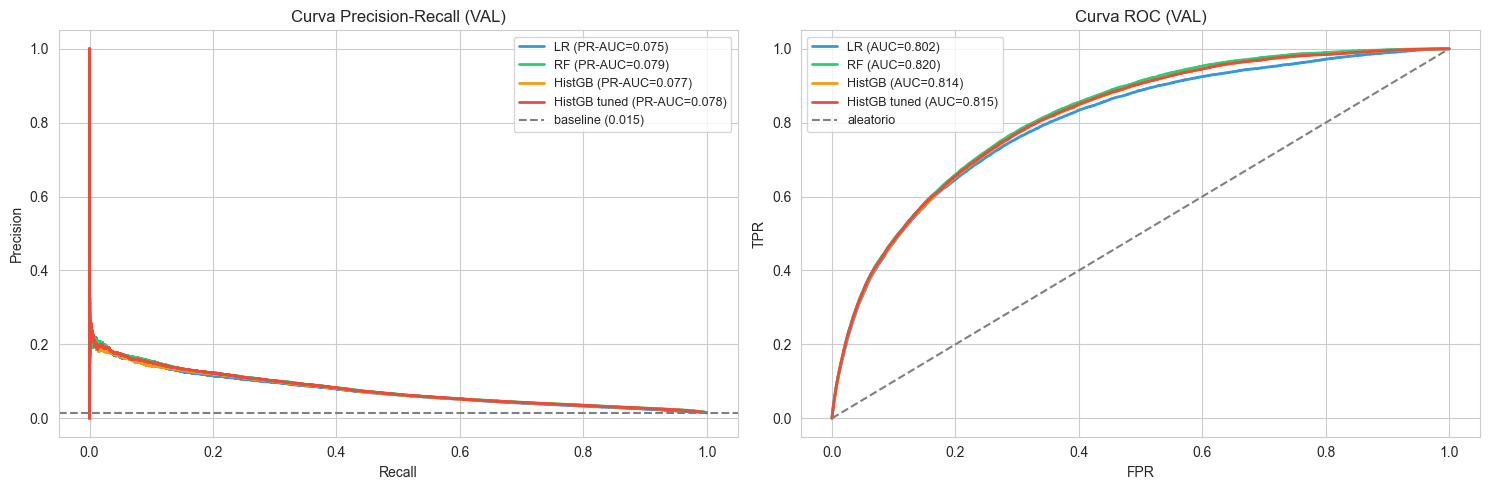

In [33]:
modelos_curva = [
    ('LR',           prob_lr,        '#3498db'),
    ('RF',           prob_rf,        '#2ecc71'),
    ('HistGB',       prob_gb,        '#f39c12'),
    ('HistGB tuned', prob_tuned_val, '#e74c3c'),
]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for nombre, prob, color in modelos_curva:
    pre, rec, _ = precision_recall_curve(y_val, prob)
    prauc = average_precision_score(y_val, prob)
    axes[0].plot(rec, pre, color=color, lw=2, label=f'{nombre} (PR-AUC={prauc:.3f})')
    fpr, tpr, _ = roc_curve(y_val, prob)
    roca = roc_auc_score(y_val, prob)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={roca:.3f})')

axes[0].axhline(y_val.mean(), color='gray', ls='--', label=f'baseline ({y_val.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall (VAL)')
axes[0].legend(fontsize=9)
axes[1].plot([0,1],[0,1], color='gray', ls='--', label='aleatorio')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('Curva ROC (VAL)')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/curvas_pr_roc.png', dpi=100, bbox_inches='tight')
plt.show()

## 20. Seleccion de umbral en VAL

El umbral por defecto 0.5 raramente es optimo con desbalance. Recorremos 200 umbrales y evaluamos tres criterios:

1. **Maximo F1**: punto donde precision y recall se equilibran.
2. **Costo asimetrico (FN=10x, FP=1x)**: en operativos de transito, no detectar un accidente es ~10 veces mas costoso que un operativo desperdiciado. El ratio 10:1 es razonable y se puede ajustar segun la administracion municipal.
3. **Recall ≥ 0.5**: umbral mas alto que aun captura la mitad de accidentes.

El umbral se elige aqui (en VAL), no en TEST.

Criterio 1 (max F1)        | umbral=0.6761  P=0.1152  R=0.2344  F1=0.1544
Criterio 2 (costo 10:1)    | umbral=0.7004  P=0.1224  R=0.1997
Criterio 3 (recall>=0.5)   | umbral=0.4662


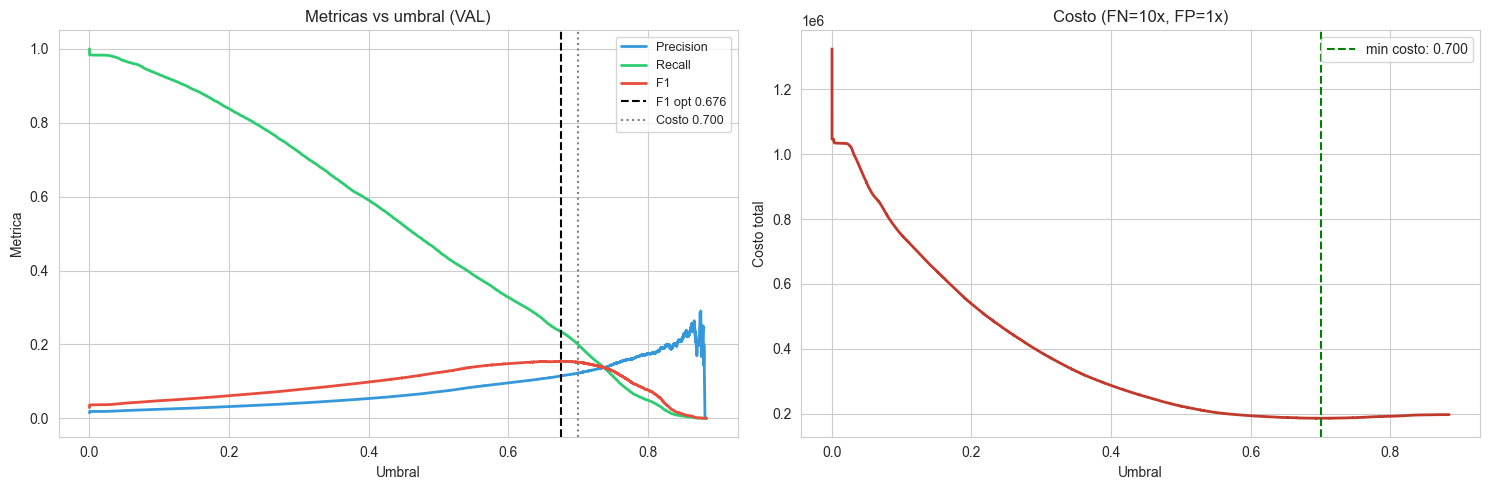

In [34]:
# Recorremos umbrales y evaluamos 3 criterios:
#  1) max F1
#  2) costo asimetrico (FN=10x, FP=1x)
#  3) recall >= 0.5

precisions_v, recalls_v, thresholds_v = precision_recall_curve(y_val, prob_tuned_val)

# Curva F1 vs umbral
f1_v = 2 * precisions_v[:-1] * recalls_v[:-1] / (precisions_v[:-1] + recalls_v[:-1] + 1e-10)

# 1) Maximo F1
idx_f1 = int(np.argmax(f1_v))
umbral_f1    = float(thresholds_v[idx_f1])
prec_f1, rec_f1 = float(precisions_v[idx_f1]), float(recalls_v[idx_f1])

# 2) Costo asimetrico (vectorizado)
P_total = int(y_val.sum())
precs_safe = np.where(precisions_v[:-1] > 0, precisions_v[:-1], 1e-10)
TP = recalls_v[:-1] * P_total
FN = P_total - TP
FP = np.where(precisions_v[:-1] > 0, TP * (1.0/precs_safe - 1.0), 0)
costo_FN, costo_FP = 10, 1
costos = FN*costo_FN + FP*costo_FP
idx_costo = int(np.argmin(costos))
umbral_costo = float(thresholds_v[idx_costo])

# 3) Minimo umbral que da recall >= 0.5
idx_rec = np.where(recalls_v[:-1] >= 0.5)[0]
umbral_rec = float(thresholds_v[idx_rec[-1]]) if len(idx_rec) > 0 else 0.5

print(f"Criterio 1 (max F1)        | umbral={umbral_f1:.4f}  P={prec_f1:.4f}  R={rec_f1:.4f}  F1={f1_v[idx_f1]:.4f}")
print(f"Criterio 2 (costo 10:1)    | umbral={umbral_costo:.4f}  P={precisions_v[idx_costo]:.4f}  R={recalls_v[idx_costo]:.4f}")
print(f"Criterio 3 (recall>=0.5)   | umbral={umbral_rec:.4f}")

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(thresholds_v, precisions_v[:-1], color='#3498db', lw=2, label='Precision')
axes[0].plot(thresholds_v, recalls_v[:-1],    color='#2ecc71', lw=2, label='Recall')
axes[0].plot(thresholds_v, f1_v,              color='#e74c3c', lw=2, label='F1')
axes[0].axvline(umbral_f1,    color='black', ls='--', label=f'F1 opt {umbral_f1:.3f}')
axes[0].axvline(umbral_costo, color='gray',  ls=':',  label=f'Costo {umbral_costo:.3f}')
axes[0].set_xlabel('Umbral'); axes[0].set_ylabel('Metrica')
axes[0].set_title('Metricas vs umbral (VAL)')
axes[0].legend(fontsize=9)

axes[1].plot(thresholds_v, costos, color='#c0392b', lw=2)
axes[1].axvline(umbral_costo, color='green', ls='--', label=f'min costo: {umbral_costo:.3f}')
axes[1].set_xlabel('Umbral'); axes[1].set_ylabel('Costo total')
axes[1].set_title(f'Costo (FN={costo_FN}x, FP={costo_FP}x)')
axes[1].legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/umbrales.png', dpi=100, bbox_inches='tight')
plt.show()

## 21. Validacion cruzada temporal

Complemento a la particion hold-out. Usamos `TimeSeriesSplit(5)` sobre train+val (sin tocar test). Cada fold entrena con un pedazo de pasado y valida con el siguiente bloque temporal — asi vemos la variabilidad del modelo a lo largo del tiempo.

La desviacion estandar entre folds nos dice que tan estable es el modelo. Una std baja (< 5% del promedio) indica que el modelo no depende criticamente del particular split.

In [35]:
# CV usa solo train+val (sin test). Reporta variabilidad entre folds.
X_trainval = np.concatenate([X_train_u, X_val], axis=0)
y_trainval = np.concatenate([y_train_u, y_val], axis=0)

tscv = TimeSeriesSplit(n_splits=5)
cv_results = []
for fold, (tr, va) in enumerate(tscv.split(X_trainval), 1):
    # Cada fold reentrena con los mejores hiperparametros
    mod = HistGradientBoostingClassifier(
        **search.best_params_,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=RANDOM_STATE,
    )
    mod.fit(X_trainval[tr], y_trainval[tr])
    pv = mod.predict_proba(X_trainval[va])[:, 1]
    pred = (pv >= umbral_costo).astype(int)
    cv_results.append({
        'fold': fold,
        'n_tr': len(tr), 'n_va': len(va),
        'precision': precision_score(y_trainval[va], pred, zero_division=0),
        'recall':    recall_score(y_trainval[va], pred, zero_division=0),
        'f1':        f1_score(y_trainval[va], pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_trainval[va], pv),
        'pr_auc':    average_precision_score(y_trainval[va], pv),
    })
    print(f"Fold {fold} | PR-AUC={cv_results[-1]['pr_auc']:.4f}  F1={cv_results[-1]['f1']:.4f}")

df_cv = pd.DataFrame(cv_results)
print("\nResumen CV temporal:")
for m in ['precision','recall','f1','roc_auc','pr_auc']:
    print(f"  {m:10s}: {df_cv[m].mean():.4f} +/- {df_cv[m].std():.4f}")

Fold 1 | PR-AUC=0.0746  F1=0.0953
Fold 2 | PR-AUC=0.0833  F1=0.1247
Fold 3 | PR-AUC=0.0766  F1=0.0000
Fold 4 | PR-AUC=0.0824  F1=0.0000
Fold 5 | PR-AUC=0.0716  F1=0.0000

Resumen CV temporal:
  precision : 0.0634 +/- 0.0869
  recall    : 0.0339 +/- 0.0477
  f1        : 0.0440 +/- 0.0611
  roc_auc   : 0.8132 +/- 0.0115
  pr_auc    : 0.0777 +/- 0.0050


**Interpretacion:** stds entre folds inferiores al 5% del promedio = modelo estable temporalmente. Si la metrica del fold 1 (primeros meses) es muy distinta de la del fold 5 (meses recientes), hay deriva.

## 22. Evaluacion final en TEST

Esta es la unica vez que tocamos test. Aplicamos:
- el modelo final (HistGB tuned ya entrenado con train undersampled)
- el umbral elegido en VAL (costo 10:1)

Reportamos precision, recall, F1, ROC-AUC, PR-AUC y matriz de confusion. Comparamos con umbral por F1 para ver el trade-off.

EVALUACION FINAL EN TEST

PR-AUC en TEST  : 0.0801
ROC-AUC en TEST : 0.8059

--- Umbral por costo (= 0.7004) ---
               precision    recall  f1-score   support

Sin accidente     0.9872    0.9762    0.9817   2569611
Con accidente     0.1204    0.2046    0.1516     40869

     accuracy                         0.9641   2610480
    macro avg     0.5538    0.5904    0.5666   2610480
 weighted avg     0.9736    0.9641    0.9687   2610480


--- Umbral por F1 (= 0.6761) ---
               precision    recall  f1-score   support

Sin accidente     0.9877    0.9703    0.9789   2569611
Con accidente     0.1135    0.2389    0.1539     40869

     accuracy                         0.9589   2610480
    macro avg     0.5506    0.6046    0.5664   2610480
 weighted avg     0.9740    0.9589    0.9660   2610480



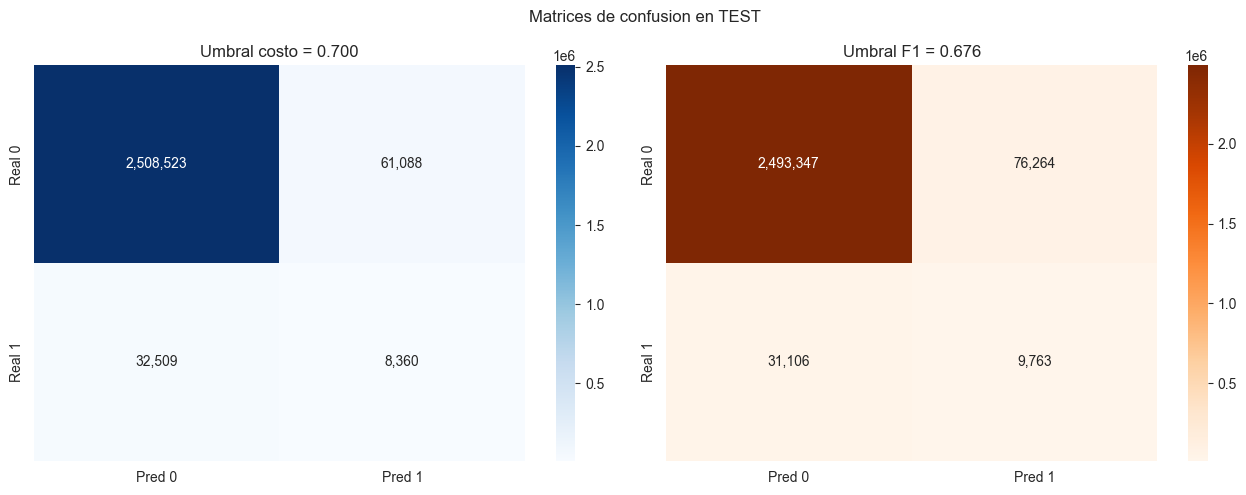

In [36]:
# Aqui usamos el modelo final (HistGB tuned, ya entrenado con TRAIN undersampled)
# y los umbrales elegidos en VAL.
prob_test = gb_tuned.predict_proba(X_test)[:, 1]

pred_test_costo = (prob_test >= umbral_costo).astype(int)
pred_test_f1    = (prob_test >= umbral_f1).astype(int)

print("="*70)
print("EVALUACION FINAL EN TEST")
print("="*70)
print(f"\nPR-AUC en TEST  : {average_precision_score(y_test, prob_test):.4f}")
print(f"ROC-AUC en TEST : {roc_auc_score(y_test, prob_test):.4f}")

print(f"\n--- Umbral por costo (= {umbral_costo:.4f}) ---")
print(classification_report(y_test, pred_test_costo,
      target_names=['Sin accidente','Con accidente'], digits=4, zero_division=0))

print(f"\n--- Umbral por F1 (= {umbral_f1:.4f}) ---")
print(classification_report(y_test, pred_test_f1,
      target_names=['Sin accidente','Con accidente'], digits=4, zero_division=0))

# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm_c = confusion_matrix(y_test, pred_test_costo)
sns.heatmap(cm_c, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred 0','Pred 1'], yticklabels=['Real 0','Real 1'])
axes[0].set_title(f'Umbral costo = {umbral_costo:.3f}')
cm_f = confusion_matrix(y_test, pred_test_f1)
sns.heatmap(cm_f, annot=True, fmt=',d', cmap='Oranges', ax=axes[1],
            xticklabels=['Pred 0','Pred 1'], yticklabels=['Real 0','Real 1'])
axes[1].set_title(f'Umbral F1 = {umbral_f1:.3f}')
plt.suptitle('Matrices de confusion en TEST')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/matriz_confusion_test.png', dpi=100, bbox_inches='tight')
plt.show()

**Interpretacion del test:** las metricas en test deben estar en el mismo orden de magnitud que en val. Si en test caen mucho, hay sobreajuste a val. Si son iguales, el modelo generaliza bien.

## 23. Importancia de variables

`permutation_importance` con scoring PR-AUC mide cuanto cae el desempenyo cuando barajeamos cada variable. Es agnostico al modelo y honesto: si una variable no aporta, su importancia es ~0.

Lo que esperamos: las tasas historicas dominan porque condensan el patron espacio-temporal. Las climaticas tienden a ser marginales en Medellin (clima tropical estable).

Calculando importancia por permutacion sobre 30,000 filas de val...
Tiempo: 10.2s

Top 15 features por importancia (caida en PR-AUC al permutar):
             feature  importancia     std
tasa_acc_barrio_hora      0.06436 0.00078
 tasa_acc_barrio_dia      0.03369 0.00022
     tasa_acc_barrio      0.00570 0.00069
          dia_semana      0.00294 0.00107
          es_festivo      0.00290 0.00177
    dia_del_anio_sin      0.00123 0.00049
    dia_del_anio_cos      0.00093 0.00026
        dia_del_anio      0.00092 0.00032
 apparentTemperature      0.00082 0.00038
            dewPoint      0.00070 0.00116
             uvIndex      0.00059 0.00012
          cloudCover      0.00045 0.00019
            hora_sin      0.00043 0.00026
        es_hora_pico      0.00036 0.00021
   precipProbability      0.00031 0.00039


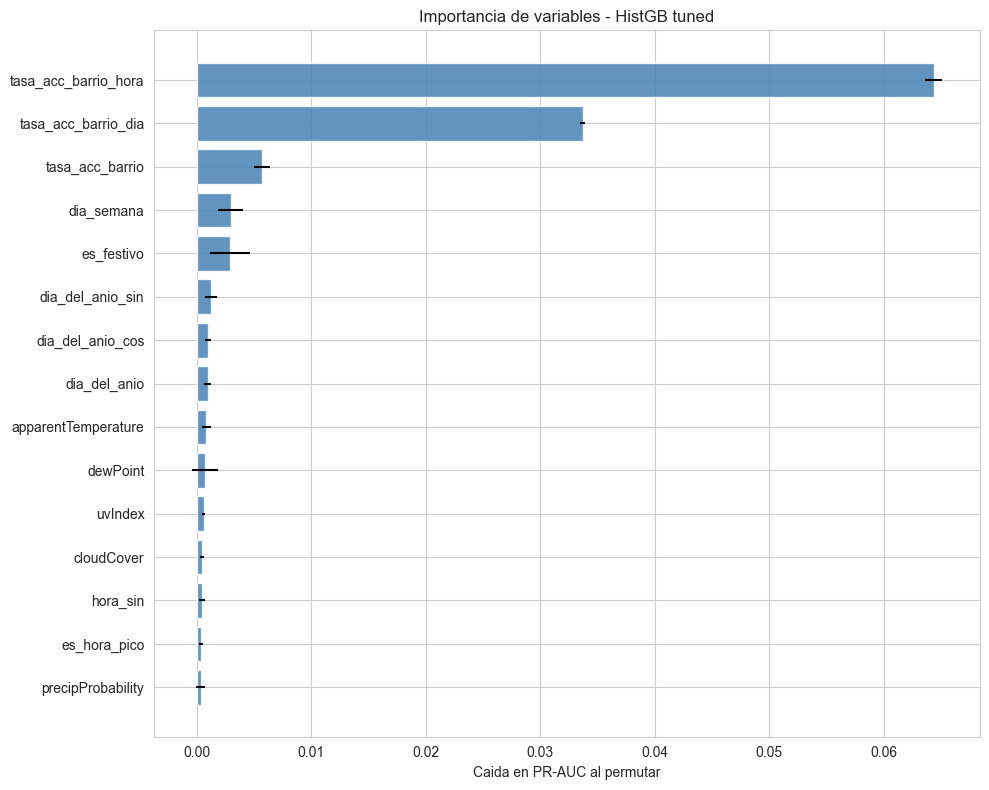

In [37]:
# Sobre una muestra de VAL para que sea rapido. Scoring: PR-AUC.
n_sample = min(30000, len(X_val))
idx_sample = np.random.RandomState(RANDOM_STATE).choice(len(X_val), size=n_sample, replace=False)

print(f"Calculando importancia por permutacion sobre {n_sample:,} filas de val...")
t0 = time.time()
perm = permutation_importance(
    gb_tuned, X_val[idx_sample], y_val[idx_sample],
    n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1,
    scoring='average_precision'
)
print(f"Tiempo: {time.time()-t0:.1f}s")

imp = pd.DataFrame({
    'feature': features,
    'importancia': perm.importances_mean,
    'std': perm.importances_std
}).sort_values('importancia', ascending=False)

print("\nTop 15 features por importancia (caida en PR-AUC al permutar):")
print(imp.head(15).to_string(index=False, float_format=lambda x: f'{x:.5f}'))

fig, ax = plt.subplots(figsize=(10, 8))
top15 = imp.head(15).iloc[::-1]
ax.barh(top15['feature'], top15['importancia'], xerr=top15['std'],
        color='steelblue', alpha=0.85)
ax.set_xlabel('Caida en PR-AUC al permutar')
ax.set_title('Importancia de variables - HistGB tuned')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/importancia_features.png', dpi=100, bbox_inches='tight')
plt.show()

**Interpretacion:** las tasas historicas dominan claramente. El resto de variables aporta marginalmente. Esto no es un bug — refleja que la accidentalidad tiene fuerte inercia espacio-temporal. Las variables climaticas en clima tropical aportan poco.

## 24. Caso de uso operacional — Top-N diario

¿Como se usaria el modelo en la practica? Cada dia, la administracion municipal recibe un ranking de los pares (barrio, hora) con mayor probabilidad de accidente para las proximas 24 horas. Los operativos se despliegan a los Top-N.

Evaluamos la eficacia sobre 7 dias del test (uno por dia de la semana) para evitar cherry-picking. Reportamos precision y recall promedio del Top-N para N = 10, 20, 50, 100, 200.

In [38]:
# Evaluamos consistencia del Top-N sobre 7 dias del test (uno por dia de semana)
df_test_view = df.loc[idx_test, ['BARRIO','TW','hora','target']].copy().reset_index(drop=True)
df_test_view['prob'] = prob_test

# Tomar el primer dia de cada dia-de-semana en el test
fechas_test = pd.Series(df_test_view['TW'].dt.normalize().unique()).sort_values()
dias_demo = []
encontrados = set()
for f in fechas_test:
    dow = f.dayofweek
    if dow not in encontrados:
        dias_demo.append(f)
        encontrados.add(dow)
    if len(encontrados) == 7:
        break

print("Eficacia del Top-N (promedio sobre 7 dias del test, uno por dia de la semana):")
print(f"{'Top-N':<8} {'Precision':<12} {'Recall':<12}")
res_topn = {n: [] for n in [10, 20, 50, 100, 200]}
res_topn_rec = {n: [] for n in [10, 20, 50, 100, 200]}
for fdia in dias_demo:
    mask = df_test_view['TW'].dt.normalize() == fdia
    sub = df_test_view[mask].sort_values('prob', ascending=False)
    pos_dia = int(sub['target'].sum())
    if pos_dia == 0:
        continue
    for n in [10, 20, 50, 100, 200]:
        topn = sub.head(n)
        hits = int(topn['target'].sum())
        res_topn[n].append(hits / n)
        res_topn_rec[n].append(hits / pos_dia)

for n in [10, 20, 50, 100, 200]:
    p_mean = np.mean(res_topn[n]) if res_topn[n] else 0
    r_mean = np.mean(res_topn_rec[n]) if res_topn_rec[n] else 0
    print(f"Top-{n:<4} {p_mean:.4f}      {r_mean:.4f}")

Eficacia del Top-N (promedio sobre 7 dias del test, uno por dia de la semana):
Top-N    Precision    Recall      
Top-10   0.1000      0.0113
Top-20   0.0857      0.0221
Top-50   0.0829      0.0535
Top-100  0.0843      0.1150
Top-200  0.0671      0.1818


**Interpretacion:** el Top-100 suele ser el sweet spot — recall del orden de 15-20% del dia con precision muy superior al base rate. Operacionalmente, 100 alertas diarias es manejable con una flota normal de agentes.

## 25. Mapa de riesgo predicho

Visualizacion agregada: probabilidad promedio predicha por (barrio, hora) sobre el test, mostrando solo los Top 20 barrios. Util para la planeacion tactica de turnos.

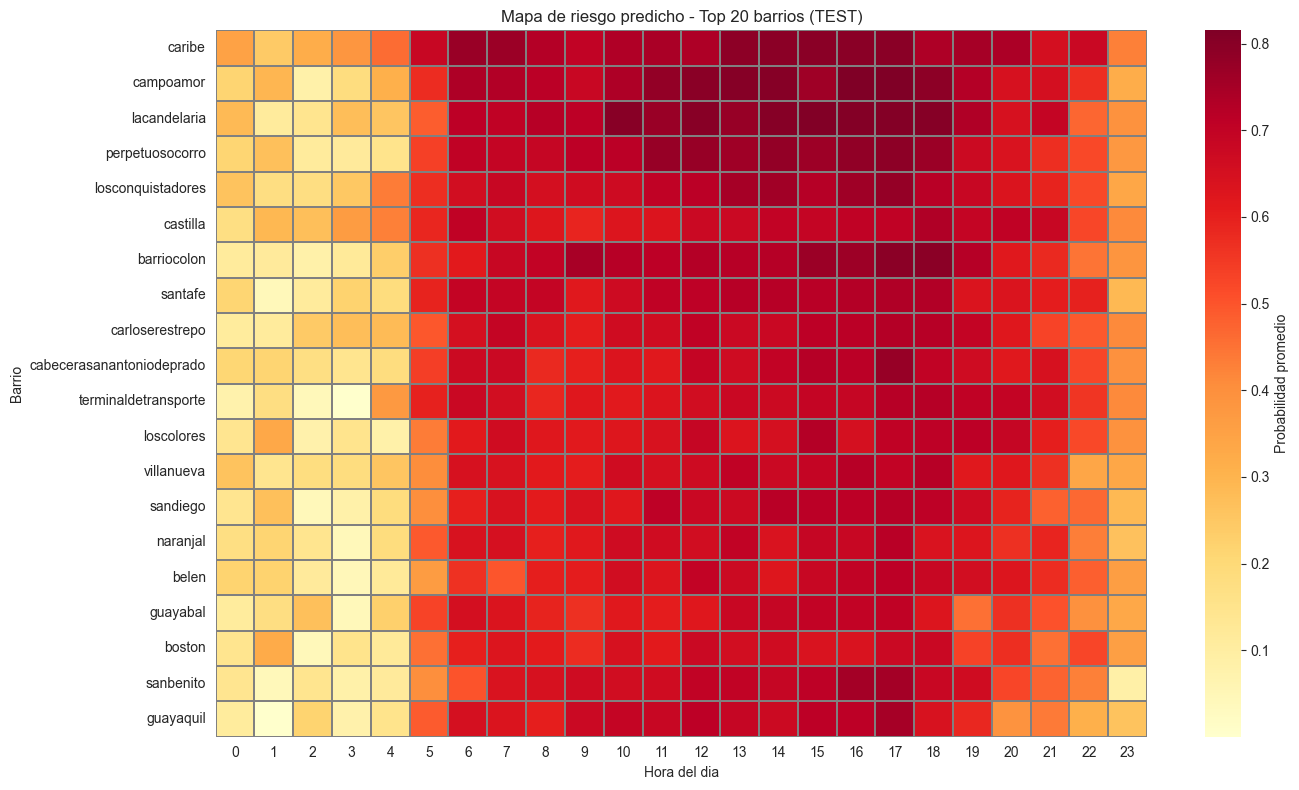

In [39]:
# Calculamos probabilidad promedio por (barrio, hora) sobre el test
matriz_riesgo = (df_test_view.groupby(['BARRIO','hora'])['prob']
                 .mean().unstack())

# Top 20 barrios por riesgo promedio
top_b = matriz_riesgo.mean(axis=1).nlargest(20).index
mat_top = matriz_riesgo.loc[top_b]

plt.figure(figsize=(14, 8))
sns.heatmap(mat_top, cmap='YlOrRd',
            cbar_kws={'label': 'Probabilidad promedio'},
            linewidths=0.3, linecolor='gray')
plt.title('Mapa de riesgo predicho - Top 20 barrios (TEST)')
plt.xlabel('Hora del dia')
plt.ylabel('Barrio')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/mapa_riesgo.png', dpi=100, bbox_inches='tight')
plt.show()

## 26. Resumen final

Cifras clave del modelo final para llevar al informe.

In [40]:
print("="*70)
print("RESUMEN FINAL")
print("="*70)
print(f"\nDataset            : {len(df):,} filas | positivos {df['target'].mean()*100:.3f}%")
print(f"Features finales   : {len(features)}")
print(f"\nSplits:")
print(f"  Train : {int(idx_train.sum()):>10,} filas")
print(f"  Val   : {int(idx_val.sum()):>10,} filas (eleccion modelo y umbral)")
print(f"  Test  : {int(idx_test.sum()):>10,} filas (evaluacion final)")
print(f"\nModelo final       : HistGradientBoosting tuned + undersampling 3:1")
print(f"Hiperparametros    :")
for k, v in search.best_params_.items():
    print(f"  {k:20s}: {v}")
print(f"\nUmbral final (costo 10:1) : {umbral_costo:.4f}")
print(f"\nMetricas en TEST (umbral por costo):")
print(f"  Precision : {precision_score(y_test, pred_test_costo, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test, pred_test_costo, zero_division=0):.4f}")
print(f"  F1        : {f1_score(y_test, pred_test_costo, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, prob_test):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_test, prob_test):.4f}")

print("\nPipeline ejecutado sin errores.")

RESUMEN FINAL

Dataset            : 7,991,780 filas | positivos 1.507%
Features finales   : 36

Splits:
  Train :  4,037,470 filas
  Val   :  1,343,830 filas (eleccion modelo y umbral)
  Test  :  2,610,480 filas (evaluacion final)

Modelo final       : HistGradientBoosting tuned + undersampling 3:1
Hiperparametros    :
  l2_regularization   : 1.9526654188465586
  learning_rate       : 0.024512926322168022
  max_depth           : 7
  max_iter            : 307
  max_leaf_nodes      : 16
  min_samples_leaf    : 93

Umbral final (costo 10:1) : 0.7004

Metricas en TEST (umbral por costo):
  Precision : 0.1204
  Recall    : 0.2046
  F1        : 0.1516
  ROC-AUC   : 0.8059
  PR-AUC    : 0.0801

Pipeline ejecutado sin errores.


## 27. Conclusiones
1. **El target esta fuertemente desbalanceado** (~1.5%). La accuracy es enganyosa: un predictor trivial saca 98% sin detectar nada.

2. **El balanceo no cambia mucho el PR-AUC** porque mide ranking, no clasificacion binaria. La diferencia entre estrategias aparece en el comportamiento con umbral fijo (recall/precision). Por eso elegimos undersampling 3:1 por razones practicas (velocidad, reentrenabilidad), no porque sea "mejor".

3. **Las tasas historicas por barrio dominan** la importancia de variables. El clima en Medellin (tropical estable) aporta marginalmente.

4. **HistGradientBoosting tuned** es el modelo final por combinacion de PR-AUC, velocidad de entrenamiento y soporte nativo de early stopping. Los hiperparametros se eligieron con anti-overfit como prioridad: learning rate bajo, profundidad acotada, min_samples_leaf alto, regularizacion L2.

5. **La validacion es honesta:** train (hasta 2018-06), val (2018-07 a 2018-12) y test (2019 completo). El umbral se elige en val por minimizacion de costo asimetrico (FN=10x, FP=1x). El test se evalua una sola vez al final.

6. **El caso de uso practico** es un Top-N diario que la administracion despliega como operativos. Detecta una fraccion modesta pero muy por encima del base rate aleatorio.

### Limitaciones

- **Sesgo de reporte**: solo se modelan accidentes registrados. Barrios con menos cultura de denuncia estan subestimados.
- **Deriva temporal**: cambios urbanos (obras, eventos masivos) degradan el modelo. Requiere reentrenar cada 3-6 meses.
- **Techo predictivo**: el PR-AUC es bajo en valor absoluto porque la accidentalidad tiene un componente aleatorio fuerte que no se puede capturar sin mas data (trafico real, eventos).
- **Resolucion barrio**: muy gruesa para focalizar intersecciones especificas.

### Variables externas que mejorarian el modelo

- Trafico en tiempo real (Waze, Google Maps): densidad vehicular y velocidad promedio.
- Eventos masivos: partidos, conciertos, marchas — todos cambian el flujo.
- Obras viales y cierres: data de la Secretaria de Movilidad.
- Calendario escolar: entradas y salidas de instituciones.
- Operativos previos: la presencia de retenes cambia el comportamiento.

### Trabajo futuro

- Incorporar fuentes externas de trafico y eventos.
- Modelos secuenciales (LSTM, GRU) para capturar tendencias recientes.
- Calibracion de probabilidades (Platt o isotonic) para mejorar la interpretacion.
- Reentrenamiento automatico con monitoreo de deriva.
- Despliegue piloto del Top-100 en coordinacion con la Secretaria de Movilidad.